<a href="https://colab.research.google.com/github/DHEVADHARSHINIV/GEN-AI/blob/main/GEN_AI_EXP_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Generating text...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Image saved as content_image.png


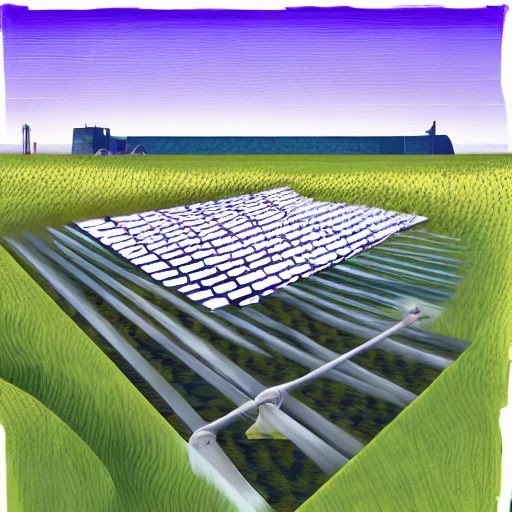


Generating audio...
Audio saved as content_audio.mp3


In [ ]:
# EXP 11
!pip -q install diffusers transformers accelerate sentencepiece gTTS

from transformers import pipeline
from diffusers import StableDiffusionPipeline
from gtts import gTTS
from IPython.display import display, Audio

# -------------------------------
# Topic
# -------------------------------
topic = "The benefits of renewable energy"

# -------------------------------
# 1. Text Generation
# -------------------------------
print("Generating text...")

text_generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-base"
)

prompt = f"Write a short engaging paragraph about {topic}."

generated_text = text_generator(
    prompt,
    max_length=80
)[0]["generated_text"]

print("\nGenerated Text:\n")
print(generated_text)

# -------------------------------
# 2. Image Generation (CPU)
# -------------------------------
print("\nGenerating image... (This may take several minutes on CPU)")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
)

image_prompt = f"An illustration representing {topic}, digital art"

image = pipe(
    image_prompt,
    num_inference_steps=25
).images[0]

image.save("content_image.png")

print("Image saved as content_image.png")

display(image)

# -------------------------------
# 3. Text-to-Speech
# -------------------------------
print("\nGenerating audio...")

tts = gTTS(text=generated_text, lang="en")
tts.save("content_audio.mp3")

print("Audio saved as content_audio.mp3")

Audio("content_audio.mp3")

In [ ]:
!pip -q install "transformers==4.53.2" diffusers accelerate sentencepiece gTTS

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 68.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
